In [109]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
from pyproj import Transformer
from project.data_handling import * 
from shop.plotting.plotting_fxns import *
import pandas as pd

site_dict = {
    'wolverine':['N','B','EC'],
    'kahiltna':['K53','K17b'], 
    'kennicott':['GTL','GTH'], # ,'KC31'],
    'lemon_creek':['B','C','D'],
    'taku':['NWB1','TKG3'],
    'gulkana':['AU','B','D']
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Compare old shading masks (slow, individual point search) to new ones (GPU / vectorized)

FileNotFoundError: Could not find shadow file: /home/claire/Local/data/shading/01.09162_shadows.nc

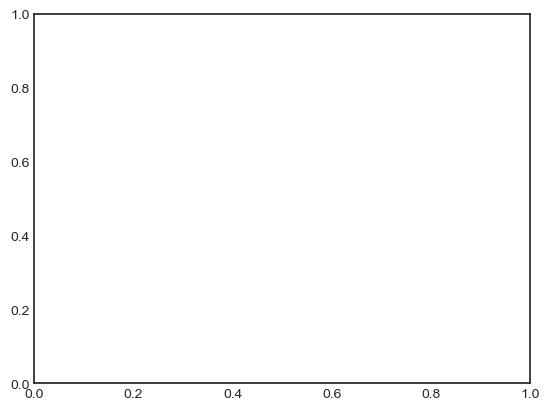

In [87]:
shading_fp = '/home/claire/Local/data/shading/'

# create figure
n_sites = np.sum([len(s) for _, s in site_dict.items()])
fig, ax = plt.subplots()
sites = []
i = 0
for glacier in site_dict:
    glacier_id = translate_rgi[glacier]['6']

    # load the shading file
    file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.nc")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find shadow file: {file_path}")

    ds = xr.open_dataset(file_path)

    # apply coordinate corrections as needed
    local_times = ds.time.values - np.timedelta64(8, "h")
    ds = ds.assign_coords(time=local_times)
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

    # read in the site constants file for this glacier
    df = pd.read_csv(f'data/by_glacier/{glacier}/site_constants.csv', index_col='site')

    for site in site_dict[glacier]:
        # grab lat/lon for this site and convert it to x/y
        point_to_grab = (df.loc[site, 'lat'], df.loc[site, 'lon'])
        transformer = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
        x_pts, y_pts = transformer.transform(point_to_grab[1], point_to_grab[0])

        # get xr DataArrays for the slicing variables
        target_x = xr.DataArray([x_pts], dims='points')
        target_y = xr.DataArray([y_pts], dims='points')

        new_ds = ds.sel(y=target_y, x=target_x, method='nearest').shadow_mask

        # load the old shadow mask
        old_mask = pd.read_csv(f'data/by_glacier/{glacier}/shade/{glacier}{site}_shade.csv', parse_dates=True, index_col=0)
        old_mask['doy'] = old_mask.index.day_of_year
        old_mask['hour'] = old_mask.index.hour

        # load the new shadow mask into a dataframe identical to old_mask
        new_mask = new_ds.to_dataframe(name='shadow_mask').reset_index()
        new_mask['doy'] = pd.DatetimeIndex(new_mask['time']).day_of_year
        new_mask['hour'] = pd.DatetimeIndex(new_mask['time']).hour

        # merge on doy/hour
        comparison = old_mask.merge(new_mask[['doy', 'hour', 'shadow_mask']], 
                                    on=['doy', 'hour'], 
                                    suffixes=('_old', '_new'))

        # calculate error metrics
        old = ~comparison['shaded']
        new = comparison['shadow_mask']
        tp = (old & new).sum()        # both say shadowed
        tn = (~old & ~new).sum()      # both say lit
        fp = (~old & new).sum()       # old says lit, new says shadowed
        fn = (old & ~new).sum()       # old says shadowed, new says lit
        n = len(old)

        # plot stacked bar chart of errors
        ax.bar(i, (tp+tn)/n, color='green')
        ax.bar(i, fp/n, bottom=(tp+tn)/n, color='red')
        ax.bar(i, fn/n, bottom=(tp+tn)/n + fp/n, color='k')
        i+= 1
        sites.append(glacier.replace('_',' ')+' '+site)
ax.bar(0, np.nan, color='green', label='Agreement')
ax.bar(0, np.nan, color='red', label='False positive')
ax.bar(0, np.nan, color='k', label='False negative')
ax.legend(bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(n_sites))
ax.set_xticklabels(sites, rotation=45, ha='right')
ax.set_title('Comparison of shading before vs after')
plt.savefig('../shading_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot the actual shadow mask for a given day of year / hours of day

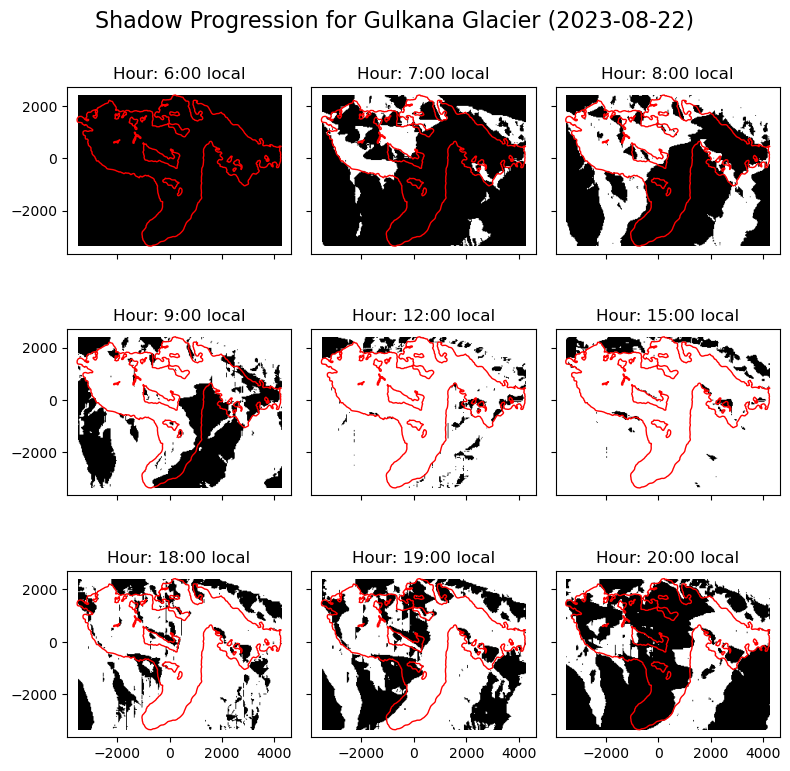

In [ ]:
shading_fp = '/home/claire/Local/data/shading/'

glacier = 'gulkana'
glacier_id = translate_rgi[glacier]['6']
date = '2023-08-22'
target_local_hours = [6, 7, 8, 9, 12, 15, 18, 19, 20]

# load the shading file
file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find shadow file: {file_path}")

ds = xr.open_dataset(file_path)

# apply coordinate corrections as needed
local_times = ds.time.values - np.timedelta64(8, "h")
ds = ds.assign_coords(time=local_times)
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

# select the day specified
date_doy = pd.to_datetime(date).day_of_year
glacier_day = ds.sel(time=ds.time.dt.dayofyear == date_doy)

# initialize plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

# load the RGI geodataframe for the shapefile
gdf = gpd.read_file('/home/claire/Local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
gdf = gdf.loc[gdf['RGIId'] == 'RGI60-'+glacier_id]
gdf = gdf.to_crs(ds.rio.crs)

# loop through hours
for i, hour in enumerate(target_local_hours):
    ax = axes[i]

    # select the specific hour slice
    hourly_data = glacier_day.sel(time=glacier_day.time.dt.hour == hour)

    # pull out 2D spatial grid
    shadow_grid = hourly_data['shadow_mask'].values.squeeze()

    # Plot the binary shadow map
    # sun = white, shade = black
    im = ax.imshow(
        shadow_grid,
        cmap="gray",
        extent=[
            ds.x.min().item(),
            ds.x.max().item(),
            ds.y.min().item(),
            ds.y.max().item(),
        ],
        origin="upper",
    )

    ax.set_title(f"Hour: {hour}:00 local")

    # plot the shapefile
    gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=1)

fig.suptitle(
    f"Shadow Progression for {glacier.replace('_',' ').capitalize()} Glacier ({date})",
    fontsize=16, y=0.98
)
plt.tight_layout()
plt.savefig('../shadow_map.png', bbox_inches='tight', dpi=300)
plt.show()

ds.close()

### Plot seasonal mass balances

In [ ]:
i = 0

all_mod_albedo = [] 
all_meas_albedo = []

for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']
        mb = MassBalance(glacier, site)
        ab = Albedo(glacier, site, 'all')

        # ds = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_22_base_0.nc') 
        ds = xr.open_zarr(f'../Output/check_4/{gn}_{i}.zarr')
        ds['time'] = ds.time - pd.Timedelta(hours=8)
        # assert ds.error.sum() < 1e-6

        mb.get_model_mb(ds)
        mb.plot_mb()
        plt.savefig(f'../figs/{glacier}{site}_best_mb.png', dpi=300)
        plt.close()
        
        ab.get_model_albedo(ds)
        # ab.get_deltas()
        for mod, meas in zip(ab.mod, ab.meas):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
        # plt.savefig(f'../figs/{glacier}{site}_best_albedo.png')
        # plt.show()
        # plt.close()

        i += 1

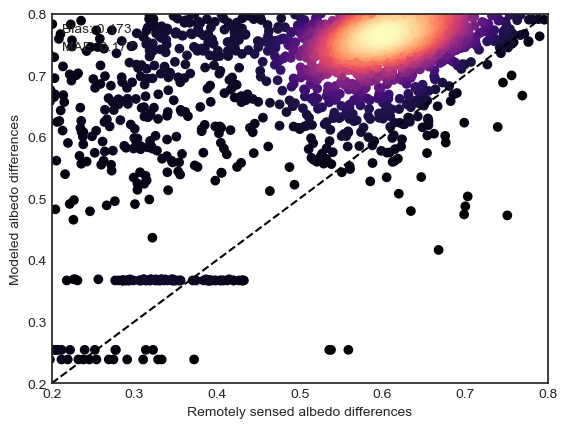

In [ ]:
mod = np.array(all_mod_albedo).flatten()
meas = np.array(all_meas_albedo).flatten()

fig, ax = plt.subplots()
from scipy.stats import gaussian_kde
xy = np.vstack([mod, meas])
kde = gaussian_kde(xy)
z = kde(xy)

idx = z.argsort()
x, y, z = meas[idx], mod[idx], z[idx]

minn, maxx = 0.2,0.8 # -0.8, 0

ax.scatter(x, y, c=z, cmap='magma')
ax.plot([minn, maxx], [minn, maxx], 'k--')
bias = np.mean(mod - meas)
MAE = np.mean(np.abs((mod - meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.90, f'MAE: {MAE:.3f}', transform=ax.transAxes)
ax.set_ylabel('Modeled albedo differences')
ax.set_xlabel('Remotely sensed albedo differences')
ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)
plt.savefig('../figs/new_albedo_agreement.png', dpi=300)
plt.show()

Beginning wolverine N (01.09162). . .

4.82945009130676
1030.6826617657518
13.303416979469837

Beginning wolverine B (01.09162). . .

4.059631417216541
831.8885284298887
10.902542809857152

Beginning wolverine EC (01.09162). . .

2.2051024490414175
242.94104418941527
4.272584314981252

Beginning kahiltna K53 (01.22193). . .

4.596725957415513
5.188540220944745
4.340112510083181

Beginning kahiltna K17b (01.22193). . .

2.636804528963637
403.5054270131551
8.633658159062835

Beginning kennicott GTL (01.15645). . .

1.3028695052580153
751.5672116830732
5.689586503916048

Beginning kennicott GTH (01.15645). . .

0.9635830232691014
188.90735478637654
2.6050071079196333

Beginning lemon_creek B (01.01104). . .

3.015096636109652
615.3010500248238
9.633289929183254

Beginning lemon_creek C (01.01104). . .

2.7081210260896817
523.1909617449825
7.669562337978297

Beginning lemon_creek D (01.01104). . .

2.523468357103615
623.7099359673722
7.373306818219685

Beginning taku NWB1 (01.01390). . .



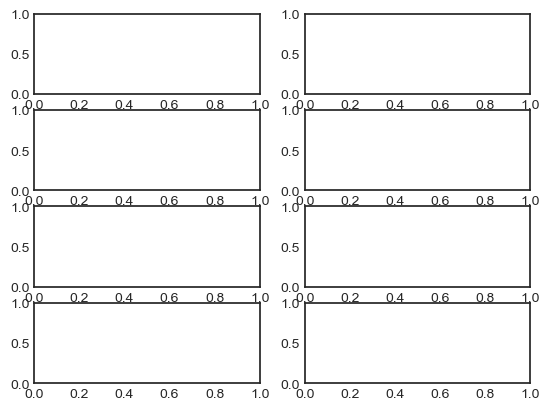

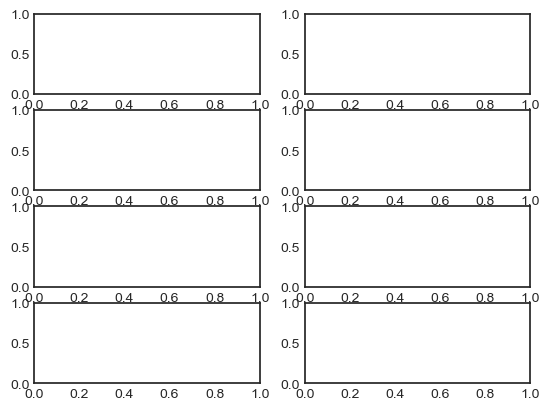

In [143]:
plot_vars = ['sensible_heat', 'latent_heat', 'shortwave_net', 'longwave_net', 'melt','refreeze','accumulation','albedo']
resample = 'D'

fig2, axes2 = plt.subplots(4, 2)
axes2 = axes2.flatten()

all_diff = {}
for var in plot_vars:
    all_diff[var] = []

fig1, axes1 = plt.subplots(4, 2)
axes1 = axes1.flatten()

all_BC = []

i = 0
for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']

        print(f'Beginning {glacier} {site} ({gn}). . .')

        
        ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_22_base_0.nc')
        ds1 = xr.open_zarr(f'../Output/check_1/{gn}_{i}.zarr').compute()

        print()
        print(ds1.where(ds1.layertype == 0).layerBC.median().values)
        print(ds1.where(ds1.layertype == 0).layerBC.max().values)
        print(ds1.where(ds1.layertype == 0).layerBC.mean().values)
        print()

#         tz = 2 if glacier != 'gulkana' else 0
#         ds0['time'] = ds0.time - pd.Timedelta(hours=tz)

#         all_BC.append(ds1.layerBC.isel(layer=0).values)

#         common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
#         # common=pd.date_range('2022-04-20','2024-04-20',freq='h')
#         ds0 = ds0.sel(time=common)
#         ds1 = ds1.sel(time=common)

#         for v, ax1 in zip(plot_vars, axes1):
#             if v == 'accumulation':
#                 v0 = 'accum' 
#             elif v == 'shortwave_in':
#                 v0 = 'SWin'
#             elif v == 'longwave_in':
#                 v0 = 'LWin'
#             elif v == 'shortwave_net':
#                 v0 = 'SWnet'
#             elif v == 'longwave_net':
#                 v0 = 'LWnet'
#             elif v.endswith('_heat'):
#                 v0 = v.split('_')[0]
#             else:
#                 v0 = v

#             if resample:
#                 if v in ['melt','accumulation', 'refreeze'] or 'shortwave' in v or 'longwave' in v or 'heat' in v:
#                     vals0 = ds0.isel(layer=0)[v0].resample(time=resample).sum().values
#                     vals1 = ds1.isel(layer=0)[v].resample(time=resample).sum().values
#                 else:
#                     vals0 = ds0.isel(layer=0)[v0].resample(time=resample).mean().values
#                     vals1 = ds1.isel(layer=0)[v].resample(time=resample).mean().values
#             else:
#                 vals0 = ds0.isel(layer=0)[v0].values 
#                 vals1 = ds1.isel(layer=0)[v].values

#             min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

#             ax1.scatter(vals0, vals1, label=glacier+site)
#             ax1.plot([min_value, max_value], [min_value, max_value], 'k--')
        
#             diff = vals1 - vals0 
#             for d in diff:
#                 all_diff[v].append(d)
            
#             ax1.set_title(v)

        i += 1

# mm =[200, 200, 200, 200, 0.005, 0.005, 0.005, 0.1]
# for v, ax2, max_abs in zip(plot_vars, axes2, mm):
#     # min_val = np.min(all_diff[v])
#     # max_val = np.max(all_diff[v])
#     # max_abs = max(abs(min_val), abs(max_val)) * 0.1
#     ax2.hist(np.array(all_diff[v]), bins=np.linspace(-max_abs, max_abs, 50))
#     ax2.set_title(v)

# fig1.supxlabel('Old CPU simulations')
# fig1.supylabel('New GPU simulations')
# fig1.set_constrained_layout(constrained=True)
# fig2.set_constrained_layout(constrained=True)
# fig1.savefig('../figs/1to1.png')
# fig2.savefig('../figs/histogram.png')
# plt.show()

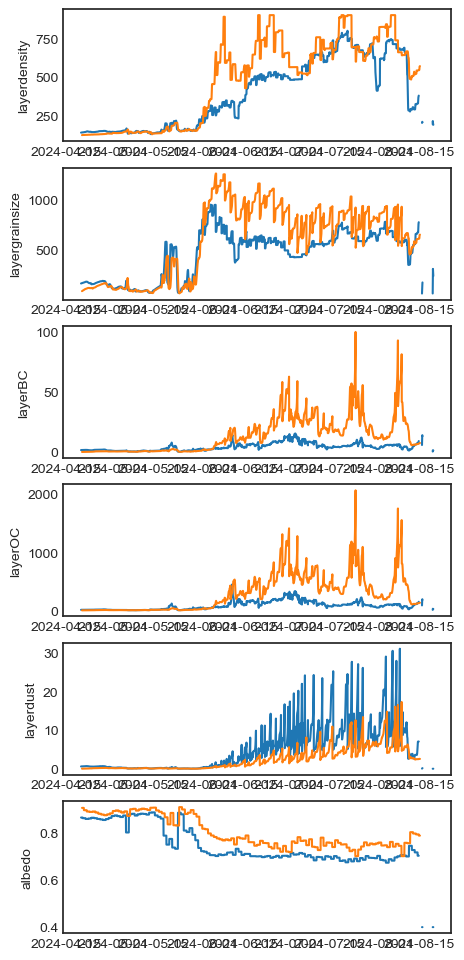

In [165]:
glacier, site = 'gulkana','D'
i = 14

gn = translate_rgi[glacier]['6']
ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_30_base_0.nc')
ds1 = xr.open_zarr(f'../Output/check_3/{gn}_{i}.zarr')

dates = pd.date_range('2024-04-20','2024-08-20', freq='h')

plot_vars = ['layerdensity','layergrainsize', 'layerBC','layerOC','layerdust','albedo']
# plot_vars = ['refreeze']
fig, axes = plt.subplots(len(plot_vars), figsize=(5, 2*len(plot_vars)))

if len(plot_vars) == 1: axes = [axes]

for ax, var in zip(axes, plot_vars):
    ax.set_ylabel(var)
    
    for _ds, label in zip([ds0,ds1], ['Before','After']):
        dates_sel = dates + pd.Timedelta(hours=8) if label =='After' else dates
        ds = _ds.sel(time=dates_sel, layer=0)
        ds = ds.where(ds.layertype == 0)
        ax.plot(ds.time, ds[var])
plt.show()



1445.0258932604872 0.6305004611651995 15.804386764165958


(array([7.073e+03, 2.023e+03, 6.080e+02, 1.590e+02, 6.000e+01, 5.400e+01,
        4.500e+01, 2.200e+01, 4.000e+00, 4.000e+00]),
 array([ 100.00010179,  234.50268094,  369.00526009,  503.50783923,
         638.01041838,  772.51299753,  907.01557667, 1041.51815582,
        1176.02073497, 1310.52331411, 1445.02589326]),
 <BarContainer object of 10 artists>)

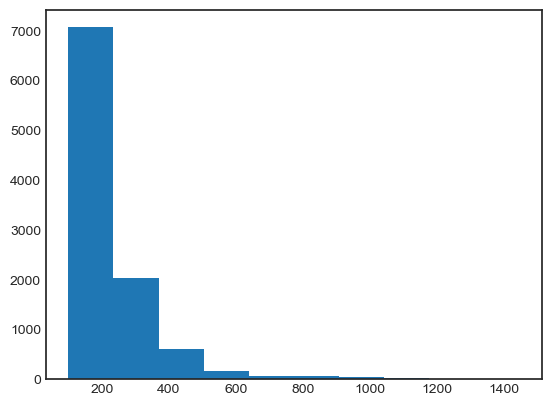

In [120]:

all_bc = ds1.layerBC.isel(layer=0).values.ravel()
print(np.max(all_bc), np.median(all_bc), np.mean(all_bc))
plt.hist(all_bc[all_bc > 100])

(<Figure size 500x680 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

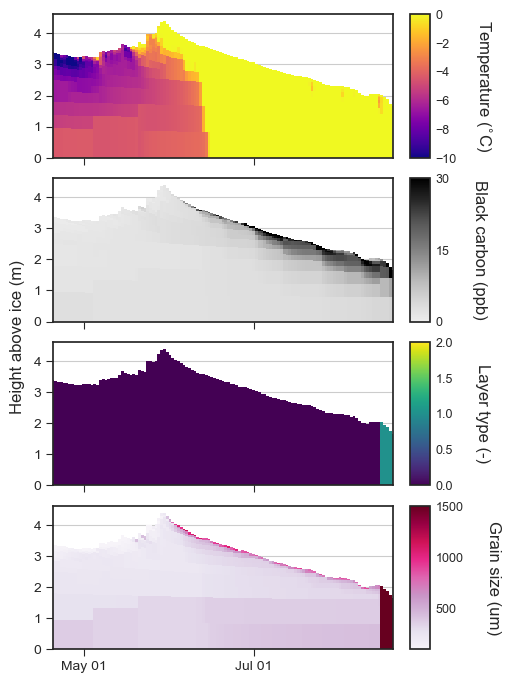

In [95]:

ds = xr.open_zarr(f'../Output/check_5/01.00570_14.zarr')

dates = pd.date_range('2024-04-20','2024-08-20', freq='D')

visualize_layers(ds, dates, ['layertemp','layerBC', 'layertype', 'layergrainsize'])